Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       177
           1       1.00      1.00      1.00      1823

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



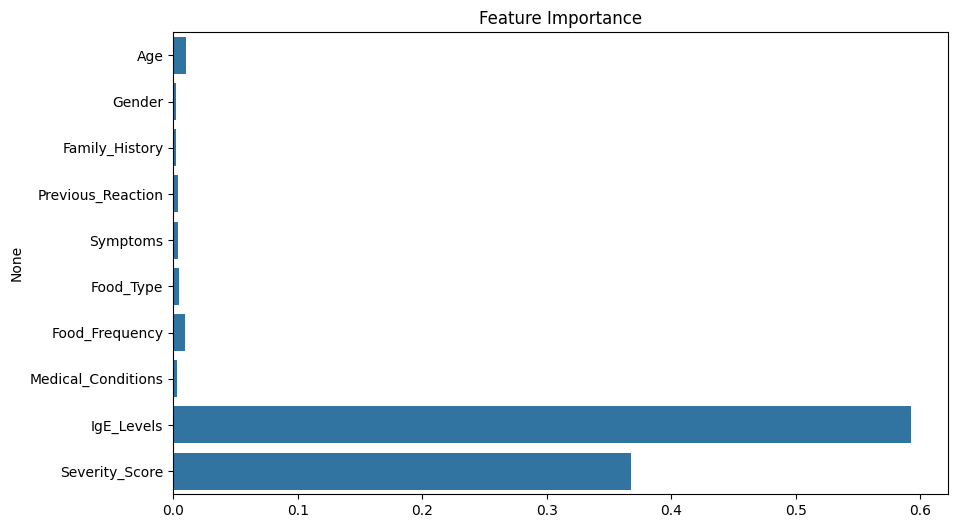

In [6]:
# Food Allergy Prediction using Random Forest



## 1. Import Libraries
#!pip install pandas numpy scikit-learn matplotlib seaborn
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns


## 2. Load Dataset

file_path = r"food_allergy_dataset (1).csv"
df = pd.read_csv(file_path)
df.head()


## 3. Preprocessing

# Encode categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns
encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

# Features and target
X = df.drop("Allergic", axis=1)
y = df["Allergic"]


## 4. Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


## 5. Train Random Forest Model

model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)


## 6. Evaluation

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


## 7. Feature Importance

importances = model.feature_importances_
feature_names = X.columns

plt.figure(figsize=(10,6))
sns.barplot(x=importances, y=feature_names)
plt.title("Feature Importance")
plt.show()


In [5]:
## 8. Save the Trained Model

import joblib

# Save the model
model_filename = "random_forest_allergy_model.pkl"
joblib.dump(model, model_filename)

print(f"Model saved as {model_filename}")


Model saved as random_forest_allergy_model.pkl
